# 7. Визуализация: от EVT-сигнала к начальному источнику

**Цель:** на Kuramoto-ряде с впрыснутым событием показать одной проверяемой фигурой (1) индикатор и POT/GPD-порог, (2) момент устойчивого EVT-превышения, (3) отклики каналов рядом с ним и (4) ранжирование предполагаемого начального источника — и явно сверить итог с известным истинным источником. Красный столбец — оценка модели; совпадение с истиной здесь проверяемо, потому что ряд синтетический и размеченный.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

# Make the local src-layout package importable when the notebook is opened
# directly in VS Code/Jupyter, without requiring an editable installation.
candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "demo/evt-educational-demo"]
ROOT = next(
    (path for path in candidates if (path / "data/generated/kuramoto_propagation_series.csv").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Cannot find the demo root. Open this notebook from the repository or demo directory."
    )
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from evt_demo.visualization import plot_evt_source_result

DATA = ROOT / "data/generated/kuramoto_propagation_series.csv"
SEED = 42
df = pd.read_csv(DATA)
channel_names = [column for column in df if column.startswith("channel_")]
x = df[channel_names].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
assert np.isfinite(x).all() and x.ndim == 2

propagation_metadata = json.loads((ROOT / "data/generated/synthetic_datasets_metadata.json").read_text())["kuramoto_propagation"]
event_onset = int(np.flatnonzero(event_mask)[0])
true_source_name = channel_names[int(propagation_metadata["source_channel"])]

In [2]:
BASELINE_SIZE = event_onset
pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=BASELINE_SIZE, tail_quantile=0.85, alarm_probability=0.97, top_k=3, persistence=1),
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    input_config=InputConfig(missing="error", require_regular_time=True),
    verbose=True,
)
result = pipeline.run_detailed(x)
assert result.detection.detected and result.ranking is not None
estimated_source = channel_names[result.ranking.source]
{
    "detected_at": result.detection.time_index,
    "true_source": true_source_name,
    "estimated_source": estimated_source,
    "source_correct": estimated_source == true_source_name,
    "probability": float(result.ranking.probabilities[0]),
}

Graph-EVT pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

{'detected_at': 949,
 'true_source': 'channel_00',
 'estimated_source': 'channel_00',
 'source_correct': True,
 'probability': 0.46973050732376864}

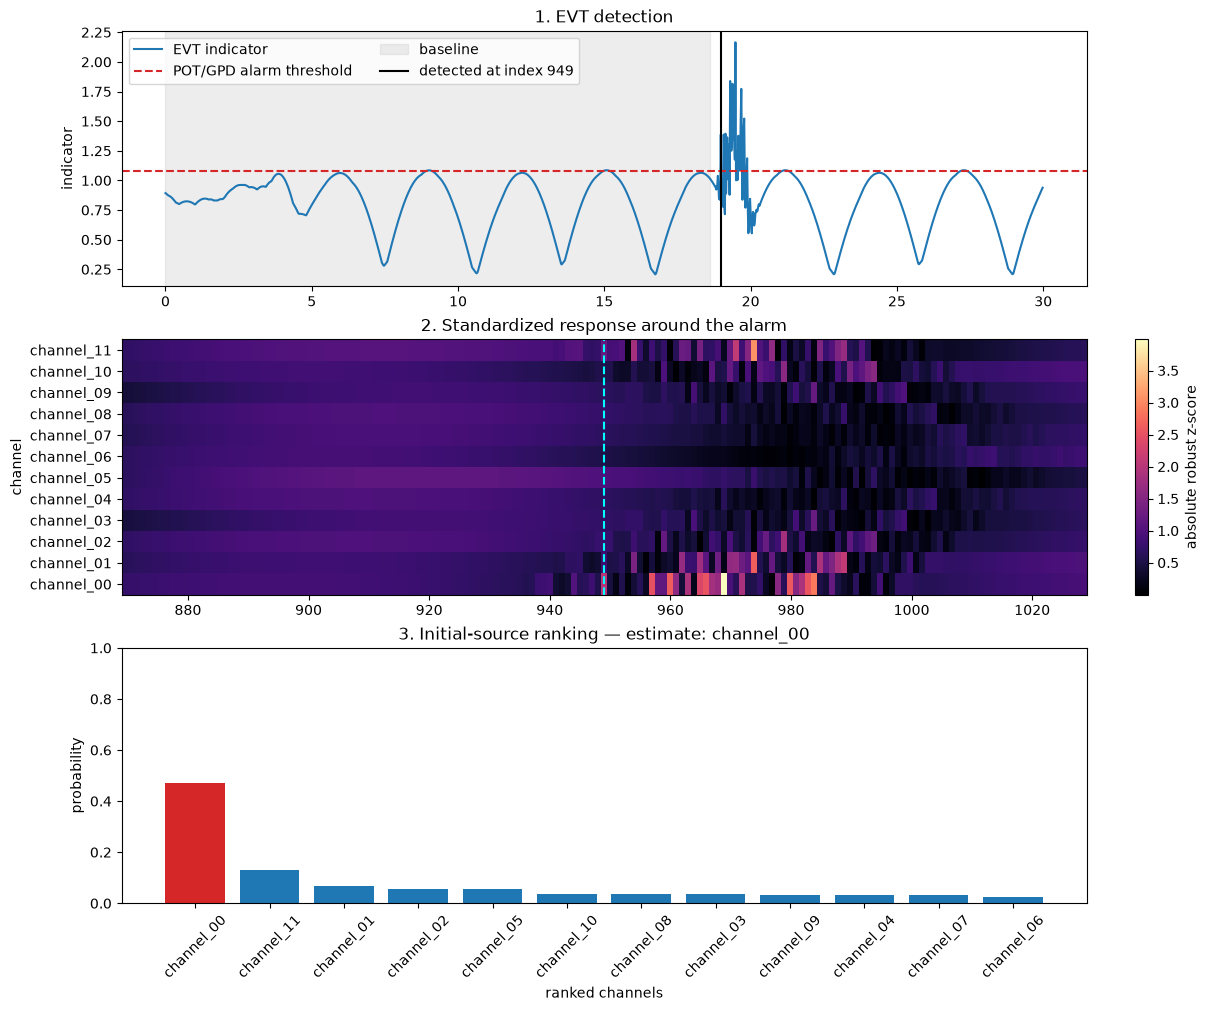

In [3]:
figure, axes = plot_evt_source_result(
    x, result, timestamps=df["timestamp"].to_numpy(), channel_names=channel_names,
    baseline_size=BASELINE_SIZE, context=80, output_path=ROOT / "figures/n-d/evt_source_result.png",
)

На верхней панели пересечение синего индикатора с красным порогом объясняет детекцию. Тепловая карта показывает нормированные реакции, использованные после тревоги. Нижняя панель показывает **всё распределение** рейтинга: первый узел — оценённый исходный источник. Здесь он проверяемо совпадает с истинным `source_channel` из метаданных генератора — но эта конкретная удача зависит от спецификации `EVTConfig` (см. ноутбук 5, где `persistence=2` на этом же ряде ошибается).